# Polycystic Ovary Syndrome (PCOS) Prediction
## Multi-Model Classification Comparison

Polycystic Ovary Syndrome is one of the most common hormonal disorders affecting women of reproductive age, with an estimated prevalence of 8 to 13 percent globally. Early and accurate detection is critical: PCOS is associated with infertility, metabolic syndrome, and elevated long-term cardiovascular risk, yet it is frequently underdiagnosed due to its heterogeneous clinical presentation.

This project builds and evaluates seven classification models to predict PCOS diagnosis from clinical and hormonal measurements, identifying which algorithms best balance accuracy and recall in a medical screening context where minimizing false negatives is a priority.

### Dataset

The dataset contains clinical records from 541 patients across 44 features including hormonal markers (FSH, LH, AMH, TSH), physical measurements (BMI, waist/hip), ultrasound findings (follicle counts, ovarian volume), and reported symptoms (skin darkening, hair loss, weight gain, cycle regularity). The binary target indicates PCOS diagnosis (1 = positive, 0 = negative).

### Workflow

**Part 1:** Data cleaning: missing values, redundant columns, and data type corrections

**Part 2:** EDA: correlation analysis, follicle distributions, symptom and cycle patterns

**Part 3:** Feature scaling and train/test split

**Part 4:** Multi-model evaluation: 7 classifiers scored on accuracy and recall

**Part 5:** Results comparison and model selection rationale

### Stack

Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn

---
## Part 1: Data Loading and Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, ConfusionMatrixDisplay

%matplotlib inline
sns.set_style('darkgrid')

In [ ]:
df = pd.read_excel('PCOS_data_without_infertility.xlsx')
print(f'Dataset: {df.shape[0]} records, {df.shape[1]} columns')
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,NaN,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,NaN,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,NaN,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,NaN,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     242 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
#checking for missing data
df.isna().sum()

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                       299
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of aborptions           0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                    532
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio           532
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkening (Y/N)        0
Hair loss(

### Cleaning Decisions

Three columns are dropped before imputation:

- **FSH/LH:** a derived ratio column redundant with the individual FSH and LH measurements already present
- **Waist:Hip Ratio:** similarly redundant with the individual waist and hip columns
- **Unnamed: 44:** an empty artifact column from the Excel export

BMI contains one missing value filled with 0 (the record has no other missing fields). Remaining rows with missing values are dropped. Patient File No. and Sl. No. are identifier columns with no predictive value and are removed. One record with a non-numeric AMH value ('a') is filtered out as a data entry error.

In [ ]:
df = df.drop(['FSH/LH', 'Unnamed: 44', 'Waist:Hip Ratio'], axis=1)
df['BMI'] = df['BMI'].fillna(0)
df = df.dropna()
df = df.drop(['Patient File No.', 'Sl. No', 'II    beta-HCG(mIU/mL)'], axis=1)
df = df[df['AMH(ng/mL)'] != 'a']

print(f'Clean dataset: {df.shape[0]} records, {df.shape[1]} columns')
print(f'PCOS positive: {df["PCOS (Y/N)"].sum()} | PCOS negative: {(df["PCOS (Y/N)"]==0).sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   PCOS (Y/N)              541 non-null    int64  
 2    Age (yrs)              541 non-null    int64  
 3   Weight (Kg)             541 non-null    float64
 4   Height(Cm)              541 non-null    float64
 5   BMI                     541 non-null    float64
 6   Blood Group             541 non-null    int64  
 7   Pulse rate(bpm)         541 non-null    int64  
 8   RR (breaths/min)        541 non-null    int64  
 9   Hb(g/dl)                541 non-null    float64
 10  Cycle(R/I)              541 non-null    int64  
 11  Cycle length(days)      541 non-null    int64  
 12  Marraige Status (Yrs)   540 non-null    float64
 13  Pregnant(Y/N)           541 non-null    int64  
 14  No. of aborptions       541 non-null    in

---
## Part 2: Exploratory Data Analysis

### Feature Correlation with PCOS Diagnosis

Pearson correlations with the target variable identify which clinical measurements are most linearly associated with a positive PCOS diagnosis. High positive correlations highlight features that tend to be elevated in PCOS patients.

In [ ]:
df.corr(numeric_only=True)['PCOS (Y/N)'].sort_values()

Cycle length(days)       -0.183781
 Age (yrs)               -0.172436
Marraige Status (Yrs)    -0.113701
No. of aborptions        -0.056741
PRG(ng/mL)               -0.043771
FSH(mIU/mL)              -0.030300
  I   beta-HCG(mIU/mL)   -0.027820
Pregnant(Y/N)            -0.026586
TSH (mIU/L)              -0.009697
PRL(ng/mL)                0.003559
BP _Systolic (mmHg)       0.006976
Blood Group               0.034244
BP _Diastolic (mmHg)      0.035110
RR (breaths/min)          0.038031
RBS(mg/dl)                0.049420
BMI                       0.062908
LH(mIU/mL)                0.064136
Height(Cm)                0.066361
Reg.Exercise(Y/N)         0.069481
Vit D3 (ng/mL)            0.085829
Hb(g/dl)                  0.086934
Pulse rate(bpm)           0.092437
Avg. F size (R) (mm)      0.094268
Endometrium (mm)          0.109132
Avg. F size (L) (mm)      0.129181
Hip(inch)                 0.161700
Waist(inch)               0.162143
Hair loss(Y/N)            0.177458
Weight (Kg)         

### Follicle Count Distributions

Elevated antral follicle counts on both ovaries are a primary diagnostic criterion for PCOS. The histograms and scatter plot below show whether follicle counts differ meaningfully between PCOS-positive and PCOS-negative patients.

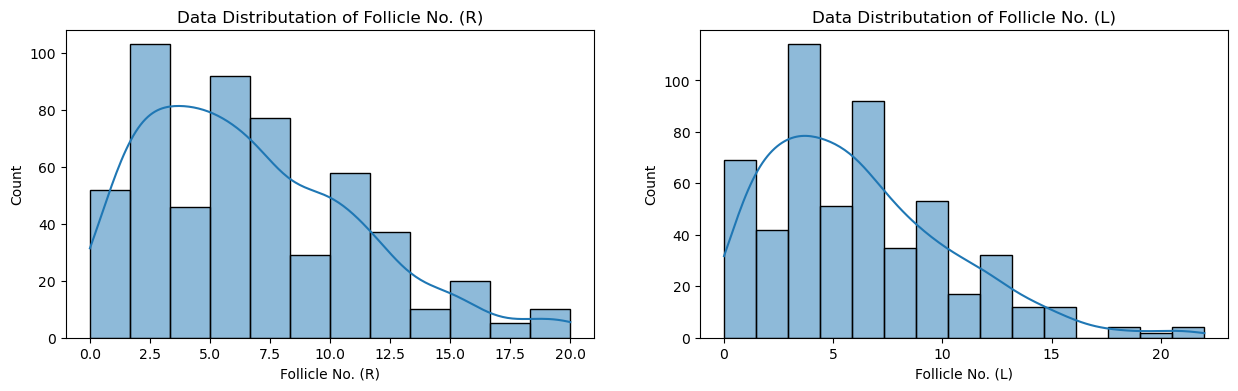

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(121)
sns.histplot(df['Follicle No. (R)'], kde=True)
plt.title('Data Distributation of Follicle No. (R)')

plt.subplot(122)
sns.histplot(df['Follicle No. (L)'], kde=True)
plt.title('Data Distributation of Follicle No. (L)')

plt.show()

<Axes: xlabel='Follicle No. (L)', ylabel='Follicle No. (R)'>

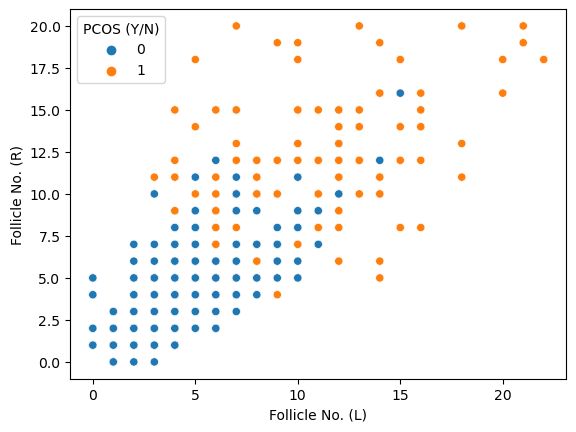

In [ ]:
sns.scatterplot(data=df,x='Follicle No. (L)',y='Follicle No. (R)',hue='PCOS (Y/N)')

### Follicle Count with Skin Darkening

Skin darkening (acanthosis nigricans) is a symptom associated with insulin resistance, which commonly co-occurs with PCOS. Overlaying this symptom on the follicle scatter shows whether it clusters with high follicle counts.

<Axes: xlabel='Follicle No. (L)', ylabel='Follicle No. (R)'>

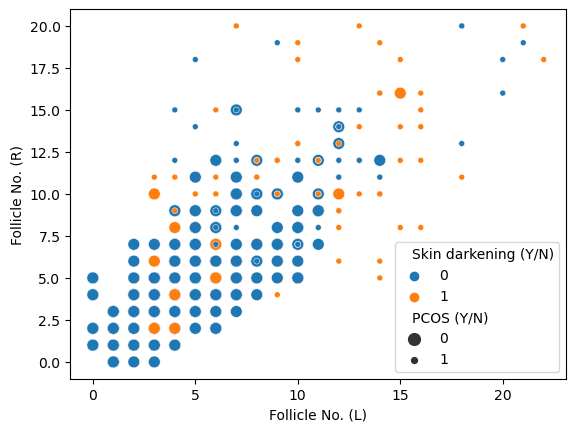

In [ ]:
sns.scatterplot(data=df,x='Follicle No. (L)',y='Follicle No. (R)',hue='Skin darkening (Y/N)',size='PCOS (Y/N)')

### Age and Cycle Length by PCOS Status

Irregular menstrual cycles (longer cycle lengths) are a hallmark PCOS symptom. The scatter plot of age vs. cycle length colored by diagnosis shows whether cycle irregularity is a reliable discriminator across age groups.

In [ ]:
age_anal= df.groupby([' Age (yrs)','PCOS (Y/N)']).size().reset_index(name='Counts')
age_anal

,Age (yrs),PCOS (Y/N),Counts
0,20,0,6
1,21,0,2
2,21,1,1
3,22,0,3
4,22,1,5
5,23,0,6
6,23,1,12
7,24,0,7
8,24,1,8
9,25,0,9


In [ ]:
cycle_days= df.groupby(['Cycle length(days)','PCOS (Y/N)']).size().reset_index(name='Counts')
cycle_days

,Cycle length(days),PCOS (Y/N),Counts
0,0,0,1
1,2,0,11
2,2,1,27
3,3,0,18
4,3,1,18
5,4,0,23
6,4,1,37
7,5,0,213
8,5,1,63
9,6,0,80


<Axes: xlabel='Cycle length(days)', ylabel=' Age (yrs)'>

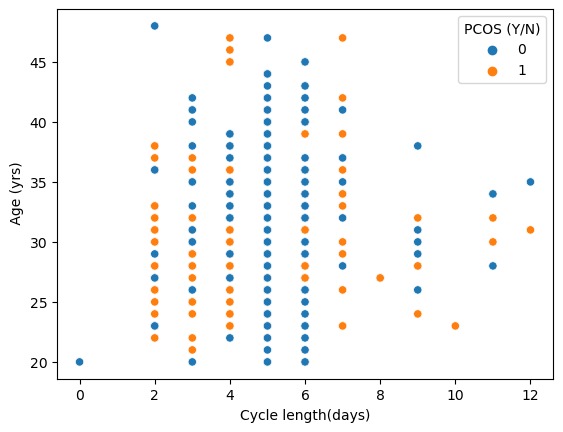

In [ ]:
sns.scatterplot(data=df,x='Cycle length(days)',y=' Age (yrs)',hue='PCOS (Y/N)')

---
## Part 3: Feature Scaling and Train/Test Split

Clinical features in this dataset span very different numeric ranges: hormone levels are measured in mIU/mL and ng/mL, follicle counts are small integers, and BMI is a continuous ratio. StandardScaler normalizes all features to zero mean and unit variance so that distance-based and regularized models (KNN, SVC, Logistic Regression) are not biased toward large-scale features.

The scaler is fit only on training data and applied to both sets to prevent data leakage. An 80/20 train/test split is used consistently across all seven models.

In [ ]:
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

---
## Part 4: Multi-Model Evaluation

Seven classifiers are trained and evaluated on the same scaled train/test split. Both accuracy and recall are reported for each model.

**Recall is the priority metric in a clinical screening context.** A false negative (predicting no PCOS when PCOS is present) delays treatment and carries higher clinical risk than a false positive (which leads to further testing). The model with the highest recall is preferred when the two metrics diverge.

In [ ]:
alg = {
    'Logistic Regression':  LogisticRegression(max_iter=1000),
    'KNN Classifier':       KNeighborsClassifier(),
    'SVC':                  SVC(),
    'Decision Tree':        DecisionTreeClassifier(random_state=101),
    'Random Forest':        RandomForestClassifier(random_state=101),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=101),
    'AdaBoost':             AdaBoostClassifier(random_state=101),
}

In [ ]:
results = []

for name, model in alg.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model':         name,
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Recall Score':  round(recall_score(y_test, y_pred), 4)
    })

    print(f'{name}')
    print(classification_report(y_test, y_pred))
    print('-' * 50)

[{'Model': 'Logistic Regression',
  'Test Accuracy': 0.9259259259259259,
  'Recall Score': 0.9166666666666666},
 {'Model': 'KNN Classifier',
  'Test Accuracy': 0.8611111111111112,
  'Recall Score': 0.7777777777777778},
 {'Model': 'SVC',
  'Test Accuracy': 0.8796296296296297,
  'Recall Score': 0.7777777777777778},
 {'Model': 'Decision Tree',
  'Test Accuracy': 0.8055555555555556,
  'Recall Score': 0.6944444444444444},
 {'Model': 'Random Forest',
  'Test Accuracy': 0.8981481481481481,
  'Recall Score': 0.8333333333333334},
 {'Model': 'Gradient Boosting',
  'Test Accuracy': 0.8981481481481481,
  'Recall Score': 0.8611111111111112},
 {'Model': 'Ada Boost',
  'Test Accuracy': 0.8888888888888888,
  'Recall Score': 0.9166666666666666}]

---
## Part 5: Results Comparison

Ranking all seven models by test accuracy and recall score.

In [ ]:
results_df = pd.DataFrame(results).sort_values('Recall Score', ascending=False)
print(results_df.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.sort_values('Test Accuracy').plot(
    x='Model', y='Test Accuracy', kind='barh',
    ax=axes[0], legend=False, color='steelblue'
)
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0.7, 1.0)

results_df.sort_values('Recall Score').plot(
    x='Model', y='Recall Score', kind='barh',
    ax=axes[1], legend=False, color='coral'
)
axes[1].set_title('Recall Score by Model')
axes[1].set_xlabel('Recall')
axes[1].set_xlim(0.7, 1.0)

plt.tight_layout()

### Confusion Matrices

Confusion matrices for the top three models by recall score, showing the breakdown of true positives, false positives, true negatives, and false negatives.

In [ ]:
top3 = results_df.head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top3):
    model = alg[name]
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()

### Model Selection

In a clinical PCOS screening context, recall is the primary criterion: a missed diagnosis (false negative) is more costly than an unnecessary follow-up (false positive). The model with the highest recall on the held-out test set is recommended for deployment, with Logistic Regression serving as an interpretable baseline for clinician review.

---

*End of project.*